# **Detecting Fraud from Customer Transactions**
<br>

## **0. Introduction**

The problem we addressed is the detection of fraudulent purchases based on purchase circumstances. This is a supervised binary classification problem.

<br>

This is important because, by predicting fraudulent purchases and potentially blocking them, we can prevent potential losses by the customer and the bureaucratic hassle involved in card chargebacks, refunds, etc.

<br>

Our model could be deployed by online merchants and commerce sites, who would use our model's predictions to prevent potentially fraudulent purchases from going through. By predicting the target variable, users of our models could see if an online transaction is likely to be fraud or not.

<br>

Our dataset, found on Kaggle, is split into two portions: transaction (590540 records) and identity (144233 records). The imbalance in records between the two datasets was something that we would eventually have to handle. These two datasets reflect different types of information: the transaction dataset (393 features) describes the actual transaction, such as cost, product information, and time, while the identity dataset (41 features) describes the customer, such as IP and device information. Much of the identity data is obscured for privacy reasons, while much of the transaction data was created by the competition host and has no obvious meaning. There is also a training and test dataset (split into transaction and identity), but the test dataset was useless to us because it does not have labels on it.

## **1. Data Prep**

In [2]:
# Modeling imports

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, cross_val_predict
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier

In [4]:
# Imports and load data
import pandas as pd
import io
#from google.colab import drive
#import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#drive.mount('/content/gdrive')

base_path = 'C:/Data/SchoolDev/cs363m/'

# Load the datasets
train_identity = pd.read_csv(f'{base_path}train_identity.csv')
train_transaction = pd.read_csv(f'{base_path}train_transaction.csv')

# TransactionID connects the two datasets
train = pd.merge(train_transaction, train_identity, on = "TransactionID", how = "left")

### 1a. Data Cleaning

To begin data cleaning, we wanted to understand how many of our features were actully giving us good information to make predictions on.

In [ ]:
train.head(20)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.500,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.000,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.000,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.000,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.000,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.000,W,5937,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.000,W,12308,360.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.500,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.000,H,2803,100.0,150.0,visa,226.0,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
9,2987009,0,86536,117.000,W,17399,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Since we saw a good amount of NaNs in the first 20 or so rows, we plotted the percentages of missing values for every feature.

Text(0, 0.5, 'Percentage of Missing Values')

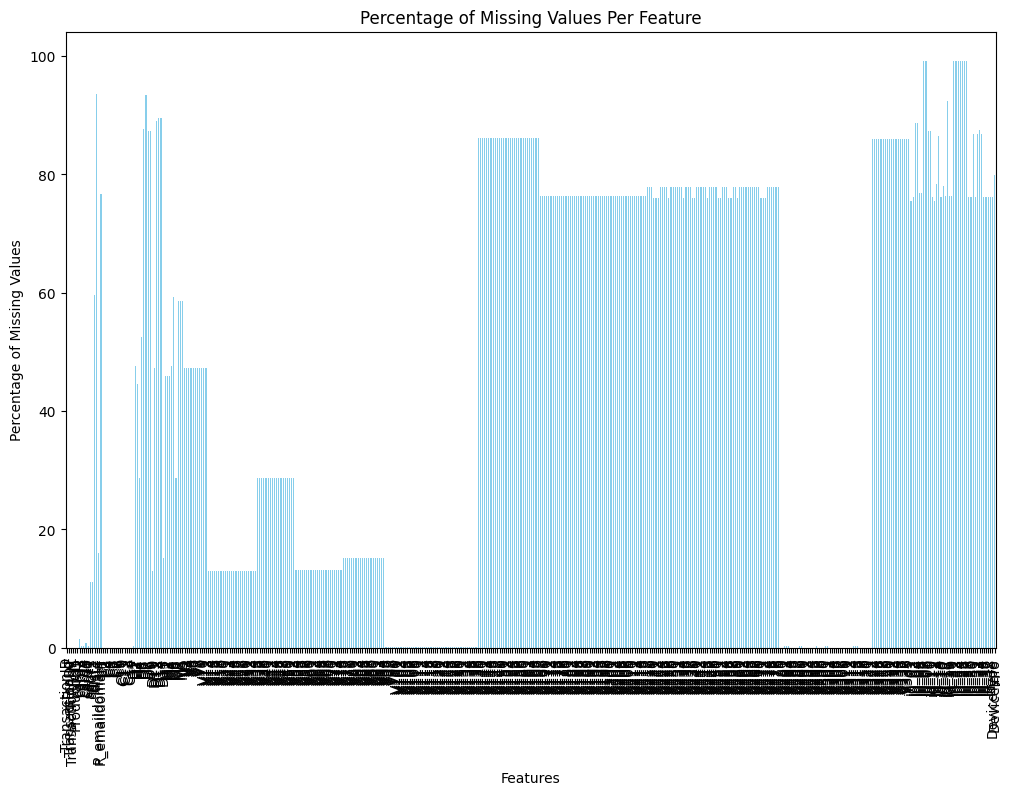

In [5]:
# prints % of missing values for all features
missing_percentages = train.isnull().mean() * 100

# Plotting
plt.figure(figsize=(12, 8))
missing_percentages.plot.bar(color='skyblue')
plt.title('Percentage of Missing Values Per Feature')
plt.xlabel('Features')
plt.ylabel('Percentage of Missing Values')

Our data cleaning consisted of dropping irrelevant columns, removing features with many missing values, and removing duplicate records.

We also did data imputing, but this took place later as part of the feature exploration process, after dropping features and records.

In [6]:
# function that does the following data cleaning strategies:
# 1. Drop irrelevant columns
# 2. Remove features with many missing values
# 3. Removes duplicates

def clean_data(dataset, drop_percent):
    # TransactionID seems to be useless after merging transaction and identity, so we drop it
    dataset.drop (["TransactionID"], axis = 1, inplace = True)

    # There are many features with excessive NANs, so we drop them instead of trying to use them
    excessive_missing = train.columns [missing_percentages > drop_percent]
    dataset.drop(excessive_missing, axis = 1, inplace = True)
    dataset.drop_duplicates(inplace = True)

### 1b. Data Exploration

We wanted to explore the dataset a bit and understand the features more. Since this fraud detection dataset is from real data from companies' transactions, many of the features are unintuitive and aren't explained thoroughly. By seeing the unique values for different features, we hoped to get a better understanding of what the features represented, so we could decide how to procede with feature engineering/removal.

In addition, we also explored the percentage of NaNs for each feature as part of our data cleaning process.

In [ ]:
# function to show the top n most frequent values for each column
def df_column_unique_values(df, top_n = 5):
    for col_name, values in df.items():
        col_value_counts = values.value_counts()

        print(f"{col_name} : {len(col_value_counts)}")

        col_value_count_list = [
            "'" + str(c) + "'" + ":" + str(n) for c, n in sorted(
                col_value_counts.items(),
                key=lambda kv: kv[1],
                reverse=True
            )
        ]

        print(", ".join(col_value_count_list[:min(len(col_value_count_list), top_n)]))

df_column_unique_values(train)

TransactionID : 590540
'2987000':1, '3380885':1, '3380689':1, '3380690':1, '3380691':1
isFraud : 2
'0':569877, '1':20663
TransactionDT : 573349
'9474817':8, '11576951':5, '4397066':5, '7236588':5, '1544629':4
TransactionAmt : 20902
'59.0':30582, '117.0':28933, '107.95':23954, '57.95':23600, '100.0':20362
ProductCD : 5
'W':439670, 'C':68519, 'R':37699, 'H':33024, 'S':11628
card1 : 13553
'7919':14932, '9500':14162, '15885':10361, '17188':10344, '15066':7945
card2 : 500
'321.0':48935, '111.0':45191, '555.0':41995, '490.0':38145, '583.0':21803
card3 : 114
'150.0':521287, '185.0':56346, '106.0':1571, '144.0':1252, '146.0':1252
card4 : 4
'visa':384767, 'mastercard':189217, 'american express':8328, 'discover':6651
card5 : 119
'226.0':296546, '224.0':81513, '166.0':57140, '102.0':29105, '117.0':25941
card6 : 4
'debit':439938, 'credit':148986, 'debit or credit':30, 'charge card':15
addr1 : 332
'299.0':46335, '325.0':42751, '204.0':42020, '264.0':39870, '330.0':26287
addr2 : 74
'87.0':520481, '6

We plotted the distribution of fraudulent transations to check if the dataset was imbalanced or not (there is a large imbalance).
We also plotted the distribution of different features for fraudulent vs non-fraudulent records to see if there was a difference. It seemed like fraudulent transactions were more likely to be expensive and more likely to be from mobile devices.

<Axes: title={'center': 'Device Types for Fraudulent Transactions'}, xlabel='DeviceType'>

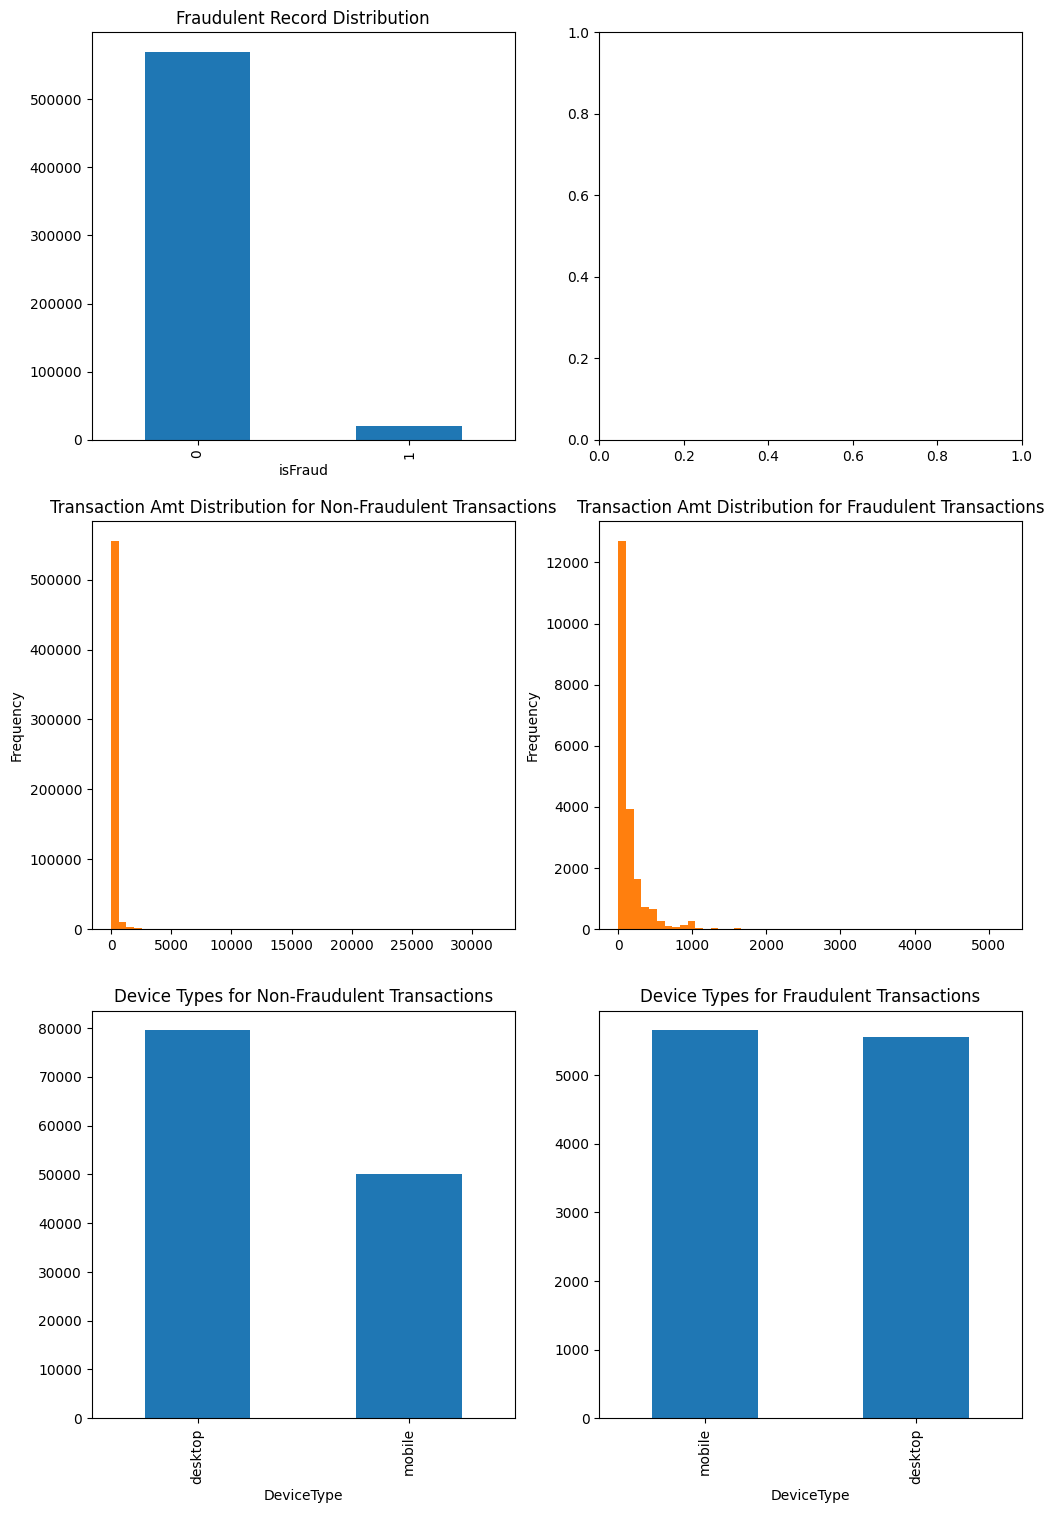

In [ ]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(12, 18))
train.groupby('isFraud').count()['TransactionID'].plot(kind='bar', title='Fraudulent Record Distribution', ax=ax1)
train[train['isFraud'] == 0]['TransactionAmt'].plot(kind='hist', bins=50, title='Transaction Amt Distribution for Non-Fraudulent Transactions', ax=ax3)
train[train['isFraud'] == 1]['TransactionAmt'].plot(kind='hist', bins=50, title='Transaction Amt Distribution for Fraudulent Transactions', ax=ax4)
train[train['isFraud'] == 0]['TransactionAmt'].plot(kind='hist', bins=50, title='Transaction Amt Distribution for Non-Fraudulent Transactions', ax=ax3)
train[train['isFraud'] == 1]['TransactionAmt'].plot(kind='hist', bins=50, title='Transaction Amt Distribution for Fraudulent Transactions', ax=ax4)
train[train['isFraud'] == 0]['DeviceType'].value_counts().plot(kind='bar', title='Device Types for Non-Fraudulent Transactions', ax=ax5)
train[train['isFraud'] == 1]['DeviceType'].value_counts().plot(kind='bar', title='Device Types for Fraudulent Transactions', ax=ax6)

To further explore our dataset, we looked at summary statistics for the dataset to give us some insights.

Note: running this in colab will cause it to run out of RAM and crash


In [ ]:
# Summary statistics
print(train.describe())

# Plotting
sns.countplot(train['isFraud'].sample(frac=0.2))
plt.show()

sns.countplot(train['card4'].sample(frac=0.2))
plt.show()

sns.countplot(train['card6'].sample(frac=0.2))
plt.show()

### 1c. Feature Engineering

For feature engineering, we knew we needed to encode our categorical features. So to start out, we found which categoricals were still left after the cleaning.

In [7]:
# function to find which categorical features are still in dataset
def find_categoricals(dataset):
    # These are all marked categorical in Kaggle
    categoricals = ["ProductCD", "P_emaildomain", "R_emaildomain", "DeviceType", "DeviceInfo"]

    # card1 - card6
    categoricals.extend([f"card{i}" for i in range(1, 7)])

    # addr1 - addr2
    categoricals.extend(["addr1", "addr2"])

    # M1 - M9
    categoricals.extend([f"M{i}" for i in range(1, 10)])

    # id_12 - id_38
    categoricals.extend([f"id_{i}" for i in range(12, 39)])

    return [feature for feature in categoricals if feature in dataset.columns]

While we did try using one-hot encoding at first, there are so many categorical features that the result was a sparce matrix data type, which isn't supported sklearn's PCA. We switched to ordinal encoding as a result.

We chose to impute a constant value that is either 0 for numeric features or "missing value" for string-valued features. Since we're running the processing pipeline outside of the CV loop for speed reasons, we can't use ffill/mean/etc for imputation without getting data leakage.

Finally, after imputing and encoding, we scaled the data and used PCA. Much of the data is on wildly different scales (for example, product cost VS credit card information), so scaling was basically necessary. The number of features is also extremely large, so PCA was used to reduce that number while also maintaining most of the data variance.

In [8]:
# function to handle ordinal encoding and imputing
# we know imputing is data cleaning, but as it was done through the same Pipeline object, it fit better here
def preprocess_data(dataset, n_components):
    categoricals = find_categoricals(dataset)
    numericals = [feature for feature in dataset.columns if feature not in categoricals]

    # Encode categorical features
    # Chose ordinal encoder because one-hot encoder produces a sparce matrix and fails PCA
    cat_pp = Pipeline([("encoder", OrdinalEncoder())], verbose = True)

    ct_pp = ColumnTransformer([("cat_pp", cat_pp, categoricals)], remainder="passthrough", verbose = True)

    # There are so many features with different ranges that scaling and PCA are mandatory
    pipe_pp = Pipeline([("ct_pp", ct_pp), ("imputer", SimpleImputer(strategy = "constant")), ("scaler", StandardScaler()), ("pca", PCA(n_components = n_components))], verbose = True)

    return pipe_pp.fit_transform(dataset)

We also wanted to do another, more interesting approach to feature engineering.

First, we did this by creating an hour column to group transactions by transactionDTs in some way.

Second, we checked for transactions done during "unusual hours", or the hours from midnight to 5am. We zero out the transactionAmt in this new feature column if the hour is "usual" and keep the transactionAmt if the hour is "unusual".

We didn't end up using this as it gave worse performance.

In [7]:
def create_unusual_hours_feature (dataset):
    transaction_dt_datetime = pd.to_datetime(dataset['TransactionDT'], unit='s')
    transaction_dt_datetime_hour = transaction_dt_datetime.dt.hour
    transaction_dt_datetime_unusual = transaction_dt_datetime_hour.apply(lambda x: 1 if x in [0, 1, 2, 3, 4, 5] else 0)

    dataset['amount_during_unusual_hour'] = dataset['unusual_hour'] * dataset['TransactionAmt']

This cell below shows our execution of ALL the above functionalities to prepare the dataset fully for the modeling phase.

In [9]:
X = train.copy(deep = True)

clean_data(X, drop_percent = 40)
y = X["isFraud"]
X.drop("isFraud", axis = 1, inplace = True)
# create_unusual_hours_feature (X)

X = preprocess_data(X, n_components = 0.9)

[Pipeline] ........... (step 1 of 1) Processing encoder, total=   1.1s
[ColumnTransformer] ........ (1 of 2) Processing cat_pp, total=   1.1s
[ColumnTransformer] ..... (2 of 2) Processing remainder, total=   0.0s
[Pipeline] ............. (step 1 of 4) Processing ct_pp, total=   2.1s
[Pipeline] ........... (step 2 of 4) Processing imputer, total=   2.7s
[Pipeline] ............ (step 3 of 4) Processing scaler, total=   1.5s
[Pipeline] ............... (step 4 of 4) Processing pca, total=  14.3s


## **2. Modeling**

### 2a. Different Modeling Techniques

We chose a number of different models for classification for our dataset.

We started with a logistic regression approach, as it was simple, quick and easy to train, and we thought it was best to start with a good baseline.

Next, we employed several ensemble methods (random forest, adaptive boosting, and gradient boosting), since we believed these would perform better as they are able to have more diverse decision boundaries. They also train relatively quickly with few resources, and hitting Colab usage limits was an actually serious issue that we faced. In particular, gradient boosting was noticeably worse than the others, took forever to train, and had to be run locally.

Then, we tried a neural network because we wanted to utilize deep learning in an attempt to find deeper connections between the features. However, again because of Colab usage limits, we could not create a particularly deep or wide neural network, and it still took an extremely long time to train.

In [11]:
# Baseline comparison
lr_clf = LogisticRegression()
rf_clf = RandomForestClassifier()
# In our local testing, ExtraTreeClassifier was much faster and slightly better performance-wise than default (DecisionTreeClassifier)
ab_clf = AdaBoostClassifier(estimator=ExtraTreeClassifier())
gb_clf = GradientBoostingClassifier()
nn_clf = MLPClassifier()

We tuned our models with GridSearchCV. We put special attention on model sizes (n_estimators, hidden_layer_sizes), since Colab's usage limits put a severe strain on our ability to train wider/deeper models. That was the main important feature to tune for our ensemble models - tuning other hyperparameters, such as tree depth and minimum samples per leaf, did not make much difference in local testing.

For the logistic regression model, we focused on tuning the solver. Generally, the hyperparameters we tuned didn't change much about the model accuracy/evaluations.

In addition, after PCA, the size of our dataset decreased greatly, which meant that, for our neural network, the default hidden_layer_sizes ([100]) was both too wide and not deep enough.

In [15]:
lr_params = {
    "solver": ["lbfgs", "newton-cholesky", "saga"]
}
rf_params = {
    "n_estimators": [10, 20, 40]
}
ab_params = {
    "n_estimators": [10, 20, 40]
}
gb_params = {
    "n_estimators": [10, 20, 40]
}
nn_params = {
    "hidden_layer_sizes": [[16, 16], [32, 32], [32, 32, 32]]
}

# Dataset is large enough that accuracy variation between folds is small, so small number of folds is okay to speed up training
rf_model = GridSearchCV(rf_clf, rf_params, cv=2, verbose=3, n_jobs=8)
lr_model = GridSearchCV(lr_clf, lr_params, cv=2, verbose=3, n_jobs=8)
ab_model = GridSearchCV(ab_clf, ab_params, cv=2, verbose=3, n_jobs=8)
gb_model = GridSearchCV(gb_clf, gb_params, cv=2, verbose=3, n_jobs=8)
nn_model = GridSearchCV(nn_clf, nn_params, cv=2, verbose=3, n_jobs=8)

### 2b. Model Comparison

We used this generic function to train and evaluate each model. In the end, we would see the cross-validation accuracy, as well as the confusion matrix and classification report (including metrics such as precision, recall, and F1 score).

In [13]:
def evaluate_model(model, X, y):
    preds = cross_val_predict (model, X, y, cv=2)
    print (f"confusion matrix =\n{confusion_matrix (y, preds)}")
    print (f"report =\n{classification_report (y, preds)}")

Training for all models was run locally, so the relevant cell outputs were copy-pasted into the comments

In [ ]:
evaluate_model(lr_model, X, y)
# confusion matrix =
# [[557283   2734]
#  [ 18257   2325]]
# report =
#               precision    recall  f1-score   support

#            0       0.97      1.00      0.98    560017
#            1       0.46      0.11      0.18     20582

#     accuracy                           0.96    580599
#    macro avg       0.71      0.55      0.58    580599
# weighted avg       0.95      0.96      0.95    580599

In [ ]:
evaluate_model(rf_model, X, y)
# confusion matrix =
# [[558294   1723]
#  [ 16721   3861]]
# report =
#               precision    recall  f1-score   support

#            0       0.97      1.00      0.98    560017
#            1       0.69      0.19      0.30     20582

#     accuracy                           0.97    580599
#    macro avg       0.83      0.59      0.64    580599
# weighted avg       0.96      0.97      0.96    580599

In [ ]:
evaluate_model(ab_model, X, y)
# confusion matrix =
# [[557821   2196]
#  [ 16789   3793]]
# report =
#               precision    recall  f1-score   support

#            0       0.97      1.00      0.98    560017
#            1       0.63      0.18      0.29     20582

#     accuracy                           0.97    580599
#    macro avg       0.80      0.59      0.63    580599
# weighted avg       0.96      0.97      0.96    580599

In [ ]:
evaluate_model(gb_model, X, y)
# confusion matrix =
# [[558647   1370]
#  [ 18581   2001]]
# report =
#               precision    recall  f1-score   support

#            0       0.97      1.00      0.98    560017
#            1       0.59      0.10      0.17     20582

#     accuracy                           0.97    580599
#    macro avg       0.78      0.55      0.57    580599
# weighted avg       0.95      0.97      0.95    580599

In [ ]:
evaluate_model(nn_model, X, y)
# confusion matrix =
# [[554840   5177]
#  [ 16095   4487]]
# report =
#               precision    recall  f1-score   support

#            0       0.97      0.99      0.98    560017
#            1       0.46      0.22      0.30     20582

#     accuracy                           0.96    580599
#    macro avg       0.72      0.60      0.64    580599
# weighted avg       0.95      0.96      0.96    580599

For this problem, it makes sense to try to minimize false negatives i.e. we don't want to miss any fraudulent transactions, and we're ok with sometimes identifying legitimate transactions as fraudulent. Because of that, we care the most about recall, which the neural network had the best performance with (0.22). We suspect part of the reason for the poor performance is the large class imbalance in the dataset, giving us relatively few fraudulent transactions to learn off of.

In [ ]:
nn_model.fit(X, y) # final fit
print(nn_model.best_params_)

# Fitting 2 folds for each of 3 candidates, totalling 6 fits
# {'hidden_layer_sizes': [16, 16]}

In [ ]:
import pickle

pickle.dump(nn_model.best_estimator_, open('nn.pkl', 'wb'))